# Assignment 03 - Field EDA

This notebook analyzes New Mexico field-level crop and soil datasets (2008-2020).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"

soil_path = DATA_DIR / "soil" / "nm_soil_data.csv"
crop_path = DATA_DIR / "crops" / "nm_cdl_2008_2020.csv"
fields_path = DATA_DIR / "boundaries" / "nm_top_200_fields.geojson"

soil_path, crop_path, fields_path
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "03_field_eda" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: /workspaces/EVTLR-Project
Figures directory: /workspaces/EVTLR-Project/notebooks/03_field_eda/figures


In [3]:
soil_df = pd.read_csv(soil_path)
crop_df = pd.read_csv(crop_path)

with open(fields_path, "r", encoding="utf-8") as f:
    fields_geojson = json.load(f)

fields_records = [feature.get("properties", {}) for feature in fields_geojson.get("features", [])]
fields_df = pd.DataFrame(fields_records)

print(f"soil_df shape: {soil_df.shape}")
print(f"crop_df shape: {crop_df.shape}")
print(f"fields_df shape: {fields_df.shape}")

soil_df shape: (3945, 16)
crop_df shape: (2587, 6)
fields_df shape: (199, 4)


In [4]:
def inspect_dataframe(df: pd.DataFrame, name: str) -> None:
    print("=" * 100)
    print(f"{name} - .info()")
    print("=" * 100)
    df.info()
    print()

    print("=" * 100)
    print(f"{name} - .describe(include='all').T")
    print("=" * 100)
    display(df.describe(include="all").T)

inspect_dataframe(soil_df, "Soil data (horizon-level)")
inspect_dataframe(crop_df, "Crop data (field-year)")
inspect_dataframe(fields_df, "Field boundaries properties")

Soil data (horizon-level) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 3945 entries, 0 to 3944
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mukey         3945 non-null   int64  
 1   muname        3945 non-null   str    
 2   compname      3945 non-null   str    
 3   comppct_r     3945 non-null   int64  
 4   drainagecl    3938 non-null   str    
 5   hzdept_r      3908 non-null   float64
 6   hzdepb_r      3908 non-null   float64
 7   om_r          3714 non-null   float64
 8   ph1to1h2o_r   3775 non-null   float64
 9   awc_r         3777 non-null   float64
 10  claytotal_r   3775 non-null   float64
 11  sandtotal_r   3350 non-null   float64
 12  silttotal_r   3350 non-null   float64
 13  dbthirdbar_r  3717 non-null   float64
 14  cec7_r        3775 non-null   float64
 15  field_id      3945 non-null   str    
dtypes: float64(10), int64(2), str(4)
memory usage: 778.0 KB

Soil data (horizon-level) - .des

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mukey,3945.0,NaN,NaN,NaN,825860.190368,684771.5043,376394.0,376434.0,376474.0,1547772.0,2606831.0
muname,3945,135,"Kimbrough-Lea complex, dry, 0 to 3 percent slopes",385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
compname,3945,102,Kimbrough,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comppct_r,3945.0,NaN,NaN,NaN,24.788847,29.83215,1.0,5.0,7.0,45.0,100.0
drainagecl,3938,5,Well drained,3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hzdept_r,3908.0,NaN,NaN,NaN,8.221085,9.942695,0.0,0.0,0.0,17.0,29.0
hzdepb_r,3908.0,NaN,NaN,NaN,42.625896,35.32959,3.0,20.0,30.0,54.25,203.0
om_r,3714.0,NaN,NaN,NaN,1.062593,0.846795,0.05,0.5,0.75,1.4,3.9
ph1to1h2o_r,3775.0,NaN,NaN,NaN,7.670861,0.440328,6.5,7.3,7.7,8.0,8.9
awc_r,3777.0,NaN,NaN,NaN,0.126402,0.033994,0.0,0.12,0.13,0.15,0.2


Crop data (field-year) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   field_id      2587 non-null   str    
 1   year          2587 non-null   int64  
 2   crop_code     2587 non-null   int64  
 3   crop_name     2587 non-null   str    
 4   dominant_pct  2587 non-null   float64
 5   total_pixels  2587 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 185.4 KB

Crop data (field-year) - .describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,2587,199,NM_FIELD_001,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2587.0,NaN,NaN,NaN,2014.0,3.742381,2008.0,2011.0,2014.0,2017.0,2020.0
crop_code,2587.0,NaN,NaN,NaN,144.117124,50.325889,1.0,152.0,152.0,176.0,236.0
crop_name,2587,17,Grassland/Pasture,1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dominant_pct,2587.0,NaN,NaN,NaN,87.279552,18.864028,19.8,81.55,97.5,100.0,100.0
total_pixels,2587.0,NaN,NaN,NaN,259.899497,186.482395,21.0,106.0,212.0,367.0,856.0


Field boundaries properties - .info()
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   field_id     199 non-null    str    
 1   county       199 non-null    str    
 2   county_fips  199 non-null    str    
 3   area_acres   199 non-null    float64
dtypes: float64(1), str(3)
memory usage: 10.3 KB

Field boundaries properties - .describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,199,199,NM_FIELD_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,199,3,Lea,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_fips,199,3,025,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_acres,199.0,NaN,NaN,NaN,560.595969,403.777943,38.334832,229.378072,454.751185,776.451273,1856.477282


In [5]:
soil_numeric_cols = [
    "comppct_r",
    "hzdept_r",
    "hzdepb_r",
    "om_r",
    "ph1to1h2o_r",
    "awc_r",
    "claytotal_r",
    "sandtotal_r",
    "silttotal_r",
    "dbthirdbar_r",
    "cec7_r",
]

for col in soil_numeric_cols:
    soil_df[col] = pd.to_numeric(soil_df[col], errors="coerce")

primary_soil = (
    soil_df.sort_values(["field_id", "comppct_r"], ascending=[True, False])
    .drop_duplicates(subset=["field_id"])
    [["field_id", "compname", "drainagecl", "muname", "mukey"]]
    .rename(
        columns={
            "compname": "soil_type",
            "drainagecl": "drainage_class",
            "muname": "map_unit_name",
        }
    )
)

soil_field_stats = soil_df.groupby("field_id", as_index=False)[soil_numeric_cols].mean()
soil_field_stats = soil_field_stats.rename(columns={c: f"{c}_field_avg" for c in soil_numeric_cols})

soil_field_df = primary_soil.merge(soil_field_stats, on="field_id", how="left")

fields_keep = fields_df[["field_id", "county", "county_fips", "area_acres"]].copy()
merged_df = (
    crop_df.merge(fields_keep, on="field_id", how="left")
    .merge(soil_field_df, on="field_id", how="left")
)
merged_df["estimated_crop_acres"] = merged_df["area_acres"] * (merged_df["dominant_pct"] / 100.0)

print(f"soil_field_df shape: {soil_field_df.shape}")
print(f"merged_df shape: {merged_df.shape}")
merged_df.head()

soil_field_df shape: (199, 16)
merged_df shape: (2587, 25)


,field_id,year,crop_code,crop_name,dominant_pct,total_pixels,county,county_fips,area_acres,soil_type,drainage_class,map_unit_name,mukey,comppct_r_field_avg,hzdept_r_field_avg,hzdepb_r_field_avg,om_r_field_avg,ph1to1h2o_r_field_avg,awc_r_field_avg,claytotal_r_field_avg,sandtotal_r_field_avg,silttotal_r_field_avg,dbthirdbar_r_field_avg,cec7_r_field_avg,estimated_crop_acres
0,NM_FIELD_001,2008,176,Grassland/Pasture,94.7,856,Roosevelt,041,1856.477282,Kimberson,Well drained,"Kimberson gravelly loam, 0 to 3 percent slopes",1547903,26.757576,8.818182,43.272727,1.572812,7.925000,0.136250,20.096875,56.587500,23.315625,1.450937,15.150000,1758.083986
1,NM_FIELD_002,2008,152,Shrubland,100.0,842,Lea,025,1795.676593,Tonuco,Excessively drained,"Tonuco loamy fine sand, 0 to 3 percent slopes",376479,23.294118,7.235294,57.470588,0.496667,7.500000,0.102353,13.470588,78.040000,9.560000,1.465294,7.794118,1795.676593
2,NM_FIELD_003,2008,152,Shrubland,88.7,829,Roosevelt,041,1795.488384,Amarose,Well drained,"Amarose loamy fine sand, 0 to 3 percent slopes",1547772,24.538462,8.948718,41.717949,0.765641,7.428205,0.109744,12.274359,78.130769,9.594872,1.508974,7.333333,1592.598196
3,NM_FIELD_004,2008,4,Sorghum,62.8,758,Roosevelt,041,1639.508575,Amarillo,Well drained,"Amarillo fine sandy loam, 0 to 1 percent slopes",1547757,26.131579,10.131579,43.157895,0.990526,7.886842,0.140526,26.368421,55.468421,18.163158,1.439211,17.965789,1029.611385
4,NM_FIELD_005,2008,176,Grassland/Pasture,100.0,724,Roosevelt,041,1588.144303,Arizer,Well drained,"Arizer sandy clay loam, 1 to 3 percent slopes",1547781,27.145455,9.236364,39.654545,1.214600,7.900000,0.127059,21.256000,52.952000,25.792000,1.442200,13.776000,1588.144303


In [6]:
inspect_dataframe(soil_field_df, "Soil data (field-level aggregates)")
inspect_dataframe(merged_df, "Merged crop + field + soil data")

Soil data (field-level aggregates) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   field_id                199 non-null    str    
 1   soil_type               199 non-null    str    
 2   drainage_class          198 non-null    str    
 3   map_unit_name           199 non-null    str    
 4   mukey                   199 non-null    int64  
 5   comppct_r_field_avg     199 non-null    float64
 6   hzdept_r_field_avg      199 non-null    float64
 7   hzdepb_r_field_avg      199 non-null    float64
 8   om_r_field_avg          199 non-null    float64
 9   ph1to1h2o_r_field_avg   199 non-null    float64
 10  awc_r_field_avg         199 non-null    float64
 11  claytotal_r_field_avg   199 non-null    float64
 12  sandtotal_r_field_avg   199 non-null    float64
 13  silttotal_r_field_avg   199 non-null    float64
 14  dbthirdb

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,199,199,NM_FIELD_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soil_type,199,42,Kimbrough,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drainage_class,198,3,Well drained,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_unit_name,199,65,"Amarillo fine sandy loam, 0 to 1 percent slopes",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mukey,199.0,NaN,NaN,NaN,758586.261307,596141.223159,376399.0,376432.5,376475.0,1547759.0,2520113.0
comppct_r_field_avg,199.0,NaN,NaN,NaN,24.721515,3.436793,16.428571,22.272727,24.9,26.893357,38.4
hzdept_r_field_avg,199.0,NaN,NaN,NaN,7.87382,1.883584,0.0,6.857143,8.266667,8.974359,12.125
hzdepb_r_field_avg,199.0,NaN,NaN,NaN,44.258703,11.76258,26.75,37.25641,41.717949,46.554627,77.25
om_r_field_avg,199.0,NaN,NaN,NaN,1.015305,0.479689,0.235714,0.654512,1.009231,1.354796,2.078571
ph1to1h2o_r_field_avg,199.0,NaN,NaN,NaN,7.636424,0.186929,7.128571,7.5,7.6,7.750926,8.19


Merged crop + field + soil data - .info()
<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   field_id                2587 non-null   str    
 1   year                    2587 non-null   int64  
 2   crop_code               2587 non-null   int64  
 3   crop_name               2587 non-null   str    
 4   dominant_pct            2587 non-null   float64
 5   total_pixels            2587 non-null   int64  
 6   county                  2587 non-null   str    
 7   county_fips             2587 non-null   str    
 8   area_acres              2587 non-null   float64
 9   soil_type               2587 non-null   str    
 10  drainage_class          2574 non-null   str    
 11  map_unit_name           2587 non-null   str    
 12  mukey                   2587 non-null   int64  
 13  comppct_r_field_avg     2587 non-null   float64
 14  hzdept_r_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,2587,199,NM_FIELD_001,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2587.0,NaN,NaN,NaN,2014.0,3.742381,2008.0,2011.0,2014.0,2017.0,2020.0
crop_code,2587.0,NaN,NaN,NaN,144.117124,50.325889,1.0,152.0,152.0,176.0,236.0
crop_name,2587,17,Grassland/Pasture,1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dominant_pct,2587.0,NaN,NaN,NaN,87.279552,18.864028,19.8,81.55,97.5,100.0,100.0
total_pixels,2587.0,NaN,NaN,NaN,259.899497,186.482395,21.0,106.0,212.0,367.0,856.0
county,2587,3,Lea,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_fips,2587,3,025,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_acres,2587.0,NaN,NaN,NaN,560.595969,402.840014,38.334832,228.510382,454.751185,784.988937,1856.477282
soil_type,2587,42,Kimbrough,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_18381/3398999657.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_acreage.head(20), x="estimated_crop_acres", y="crop_name", palette="viridis")


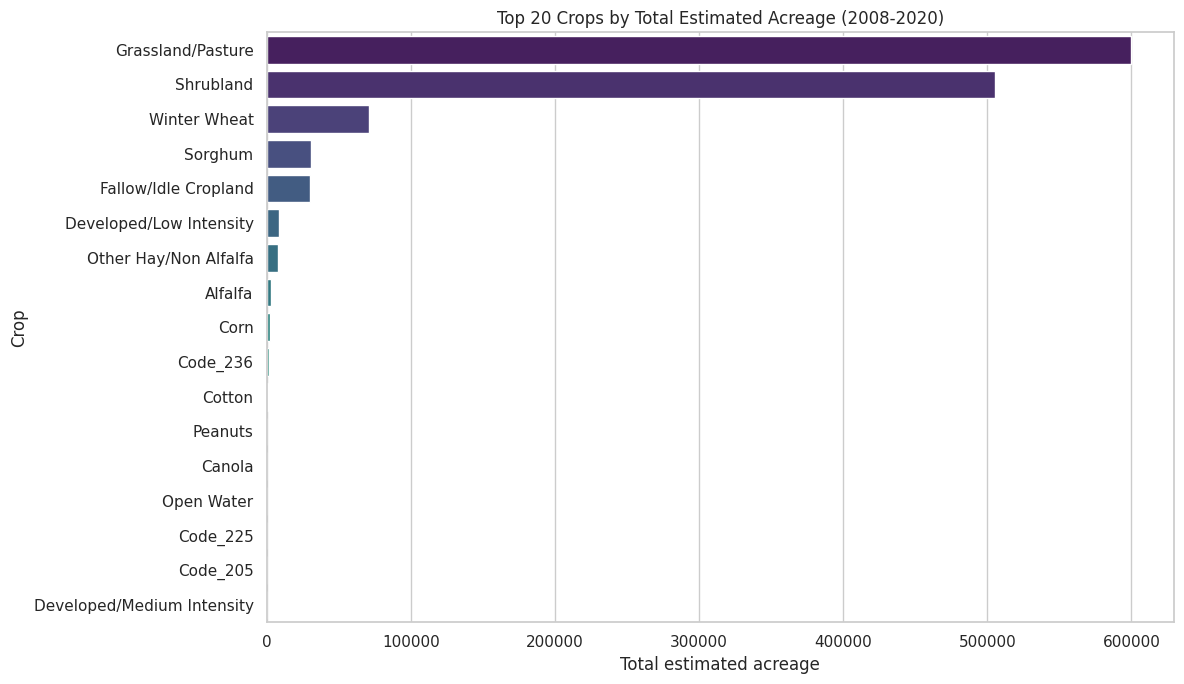

,crop_name,estimated_crop_acres
10,Grassland/Pasture,599595.779037
14,Shrubland,505143.246518
16,Winter Wheat,70882.425741
15,Sorghum,30865.304898
9,Fallow/Idle Cropland,29962.203163
7,Developed/Low Intensity,8595.081831
12,Other Hay/Non Alfalfa,8031.888414
0,Alfalfa,2933.062543
5,Corn,1963.861256
4,Code_236,1895.405302


In [7]:
crop_acreage = (
    merged_df.groupby("crop_name", as_index=False)["estimated_crop_acres"]
    .sum()
    .sort_values("estimated_crop_acres", ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(data=crop_acreage.head(20), x="estimated_crop_acres", y="crop_name", palette="viridis")
plt.title("Top 20 Crops by Total Estimated Acreage (2008-2020)")
plt.xlabel("Total estimated acreage")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_total_acreage_per_crop.png", dpi=150, bbox_inches="tight")
plt.show()

crop_acreage.head(10)

**Interpretation - Total acreage per crop**

This chart shows which crops account for the most estimated acreage over 2008-2020. Higher bars indicate crop classes that dominate field coverage more frequently and across larger fields.

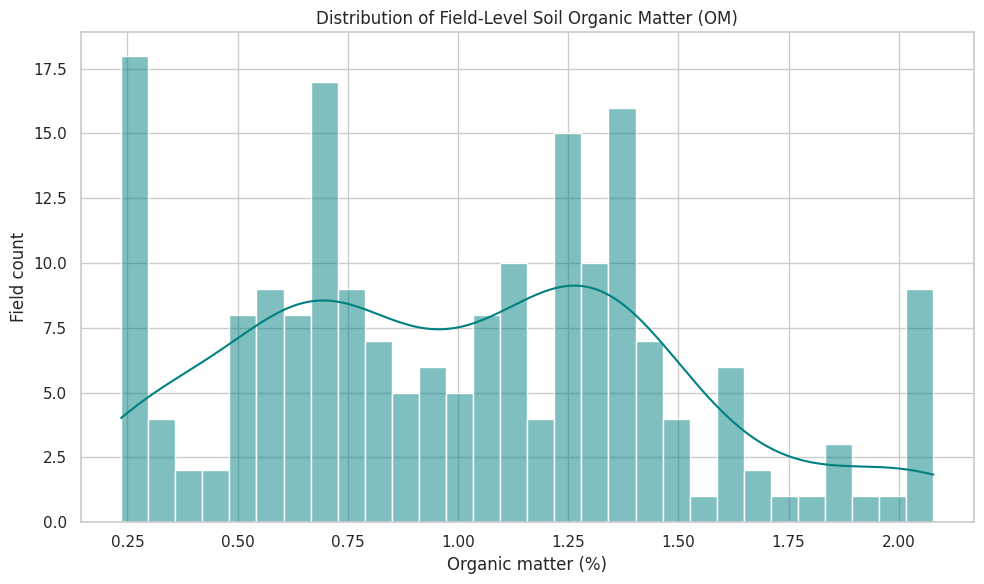

count    199.000000
mean       1.015305
std        0.479689
min        0.235714
25%        0.654512
50%        1.009231
75%        1.354796
max        2.078571
Name: om_r_field_avg, dtype: float64

In [8]:
plt.figure(figsize=(10, 6))
om_values = soil_field_df["om_r_field_avg"].dropna()
sns.histplot(om_values, kde=True, bins=30, color="teal")
plt.title("Distribution of Field-Level Soil Organic Matter (OM)")
plt.xlabel("Organic matter (%)")
plt.ylabel("Field count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_soil_organic_matter_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

om_values.describe()

**Interpretation - Soil organic matter distribution**

This distribution shows how field-level average organic matter varies across the study area. Use the histogram shape and spread to identify whether most fields cluster at low or high OM levels and whether there are notable outliers.

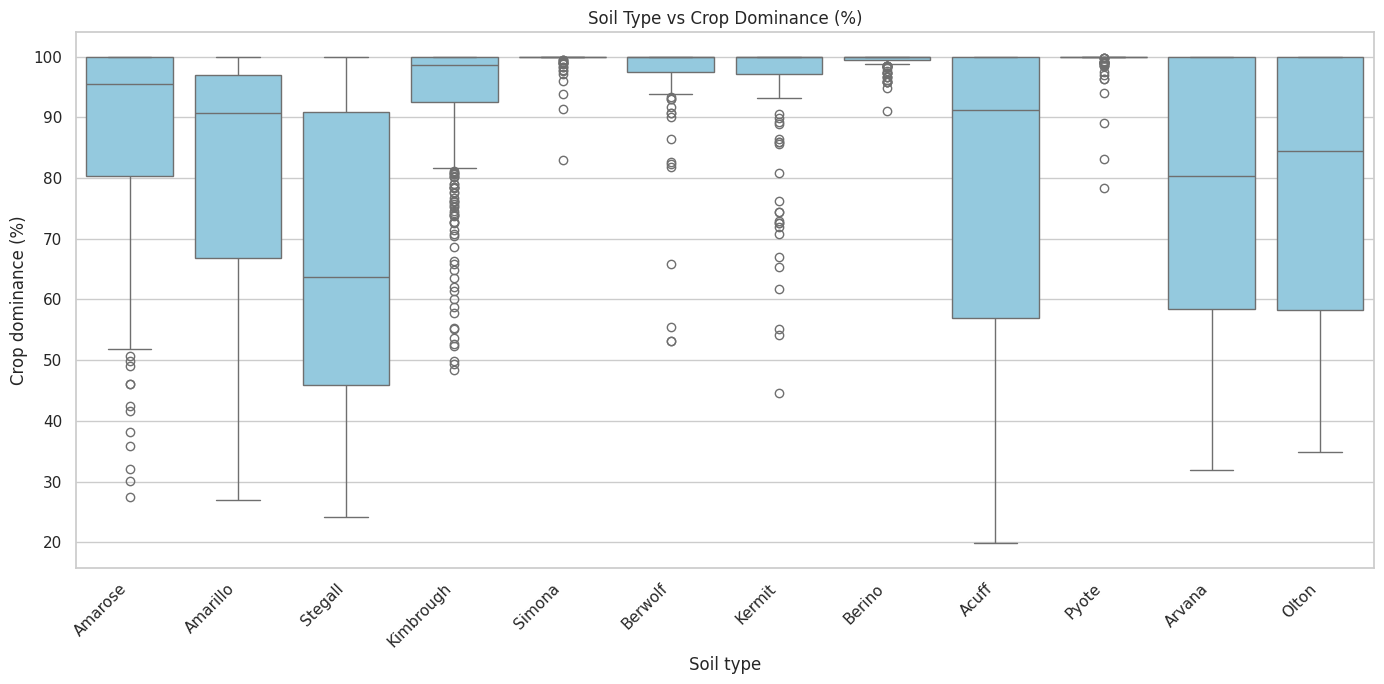

In [9]:
top_soils = merged_df["soil_type"].value_counts().head(12).index
soil_vs_dom = merged_df[merged_df["soil_type"].isin(top_soils)].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(data=soil_vs_dom, x="soil_type", y="dominant_pct", color="skyblue")
plt.title("Soil Type vs Crop Dominance (%)")
plt.xlabel("Soil type")
plt.ylabel("Crop dominance (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_soil_type_vs_crop_dominance.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation - Soil type vs crop dominance**

Boxplots compare crop dominance percentages across major soil types. Soil types with higher medians and tighter spreads tend to show more consistent dominant crop behavior.

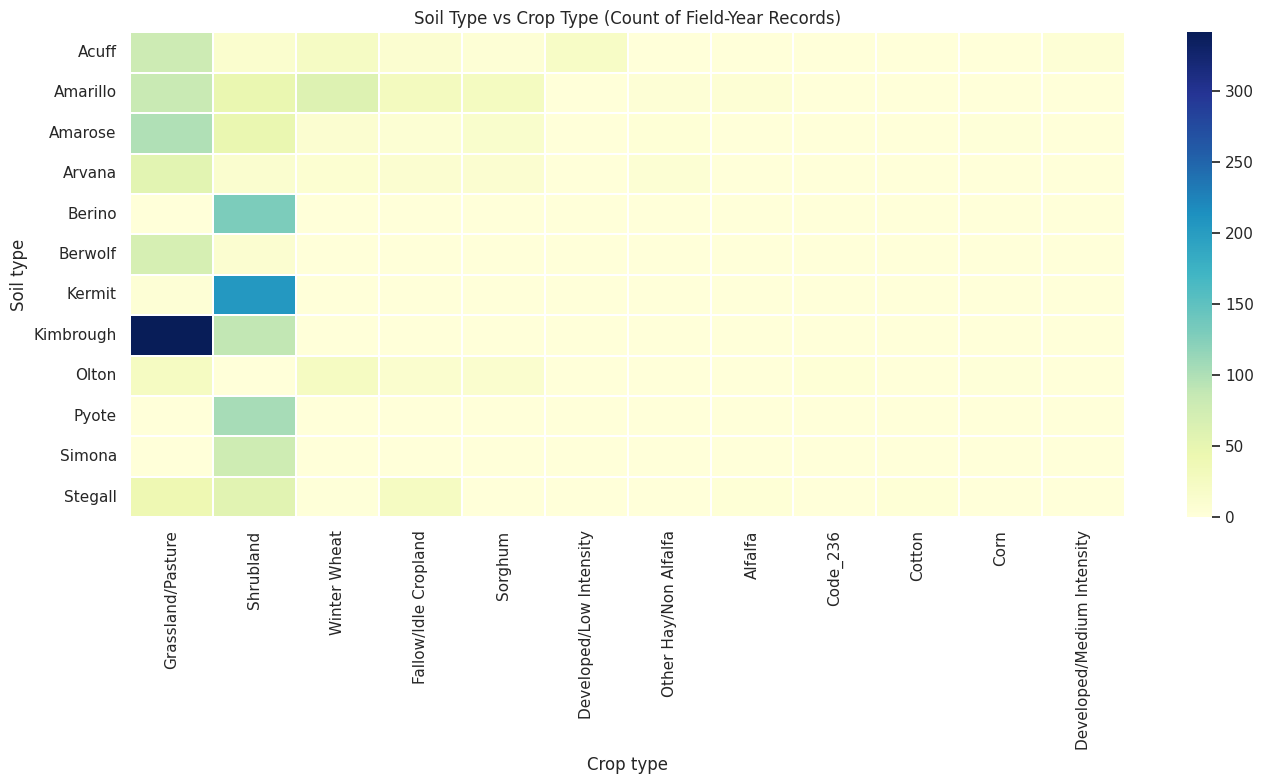

In [10]:
top_crops = merged_df["crop_name"].value_counts().head(12).index
soil_crop_ct = pd.crosstab(
    merged_df[merged_df["soil_type"].isin(top_soils)]["soil_type"],
    merged_df[merged_df["soil_type"].isin(top_soils)]["crop_name"],
)
soil_crop_ct = soil_crop_ct.reindex(columns=[c for c in top_crops if c in soil_crop_ct.columns], fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(soil_crop_ct, cmap="YlGnBu", linewidths=0.3)
plt.title("Soil Type vs Crop Type (Count of Field-Year Records)")
plt.xlabel("Crop type")
plt.ylabel("Soil type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_soil_type_vs_crop_type_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation - Soil type vs crop type**

This heatmap highlights which crop types appear most often within each major soil type. Darker cells indicate soil-crop combinations that occur more frequently in the field-year records.

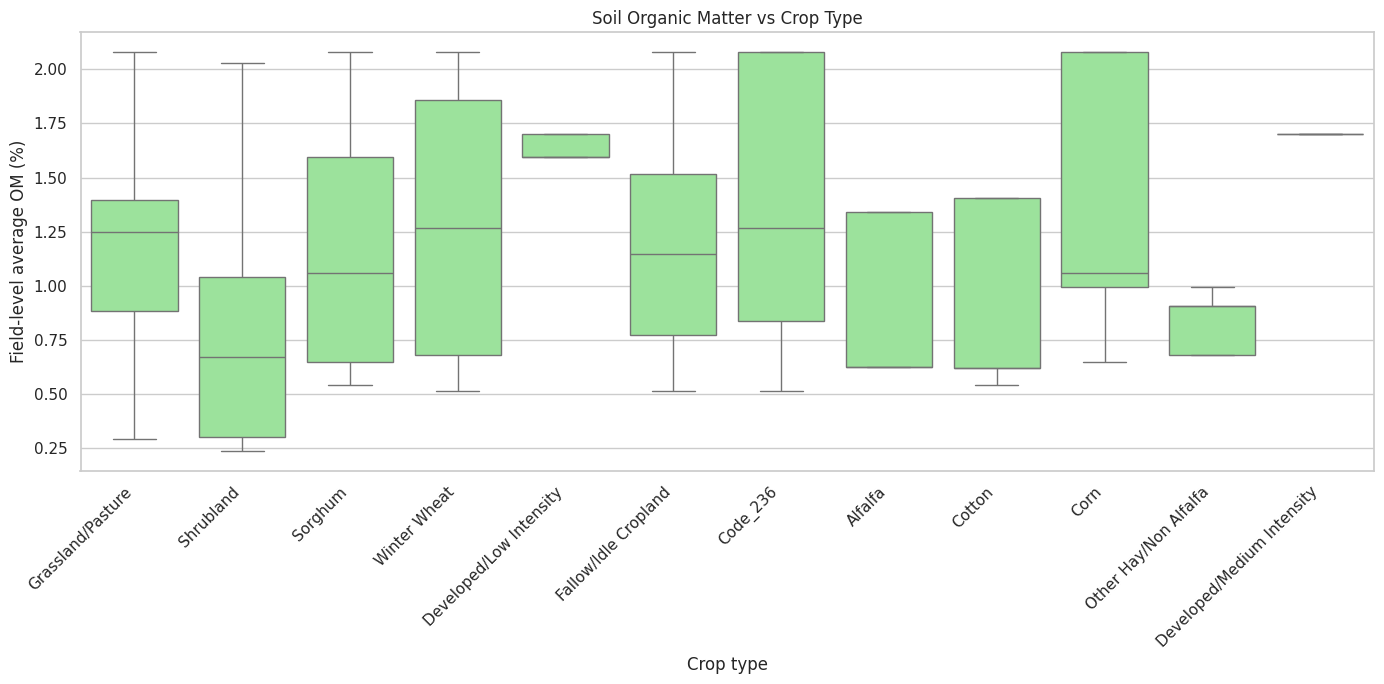

In [11]:
om_crop_df = merged_df[merged_df["crop_name"].isin(top_crops)].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(data=om_crop_df, x="crop_name", y="om_r_field_avg", color="lightgreen")
plt.title("Soil Organic Matter vs Crop Type")
plt.xlabel("Crop type")
plt.ylabel("Field-level average OM (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_organic_matter_vs_crop_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation - Organic matter vs crop type**

These boxplots compare field-level average organic matter across crop categories. Differences in medians and interquartile ranges suggest where OM conditions are generally higher or lower by crop context.

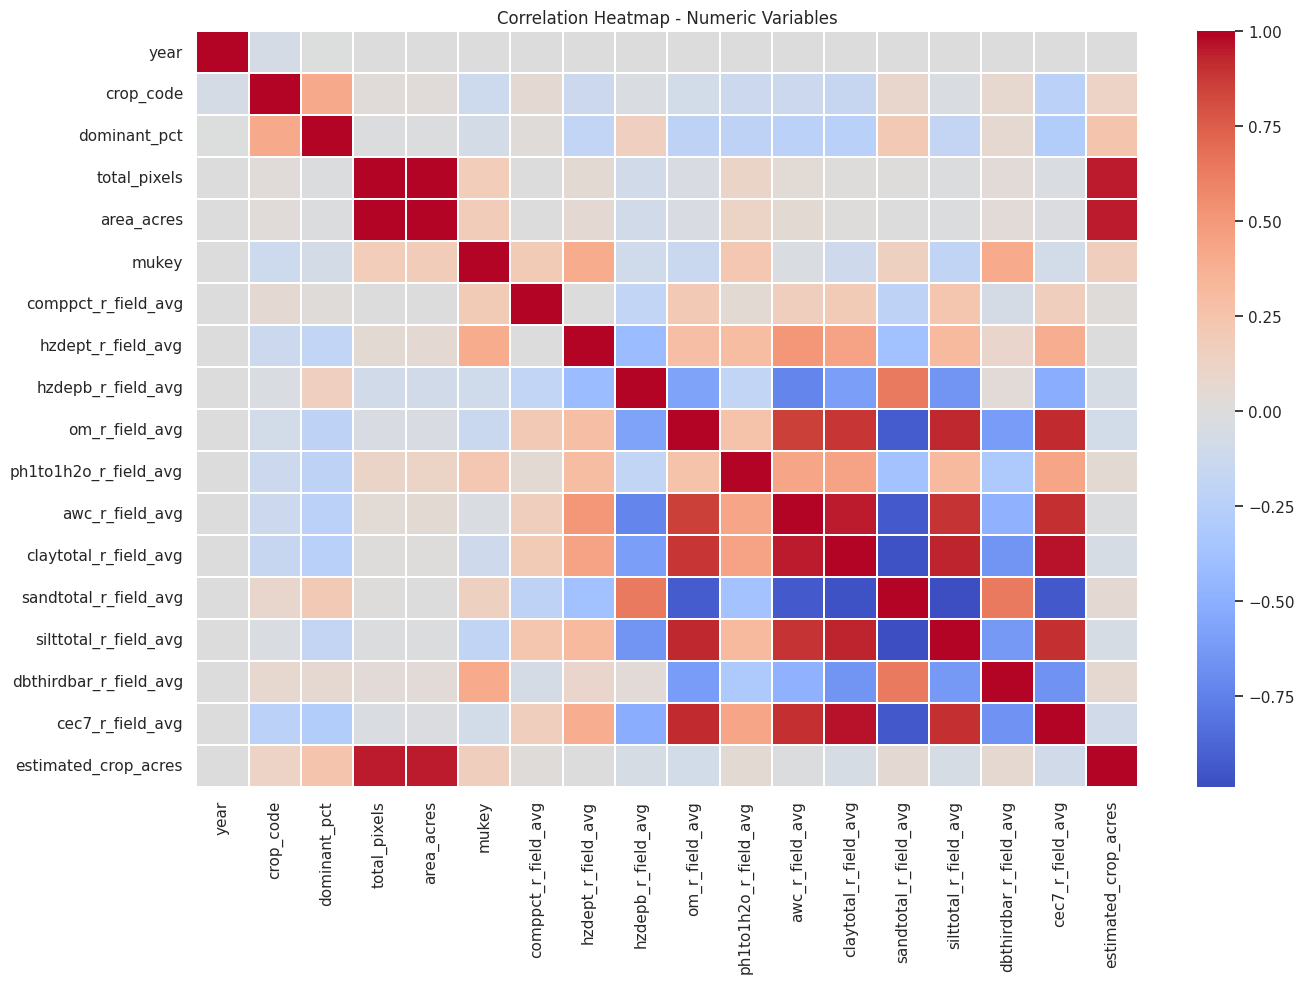

,year,crop_code,dominant_pct,total_pixels,area_acres,mukey,comppct_r_field_avg,hzdept_r_field_avg,hzdepb_r_field_avg,om_r_field_avg,ph1to1h2o_r_field_avg,awc_r_field_avg,claytotal_r_field_avg,sandtotal_r_field_avg,silttotal_r_field_avg,dbthirdbar_r_field_avg,cec7_r_field_avg,estimated_crop_acres
year,1.000000e+00,-0.060317,-0.004541,2.026111e-14,2.134112e-14,5.639293e-15,3.229991e-15,4.669986e-15,-3.364916e-15,-1.878740e-15,3.740267e-14,6.312344e-16,3.291344e-15,-1.073646e-15,1.485368e-16,2.940651e-14,-1.652500e-15,0.005207
crop_code,-6.031697e-02,1.000000,0.410023,2.719553e-02,2.420750e-02,-1.152889e-01,5.893046e-02,-1.320409e-01,-3.057014e-02,-8.692597e-02,-1.319971e-01,-1.263671e-01,-1.649624e-01,8.971192e-02,-3.101635e-02,7.191878e-02,-2.276252e-01,0.123907
dominant_pct,-4.540917e-03,0.410023,1.000000,-1.393972e-02,-1.646047e-02,-7.785138e-02,1.736463e-02,-1.855544e-01,1.591830e-01,-2.184595e-01,-2.181510e-01,-2.315148e-01,-2.444186e-01,2.115525e-01,-1.769143e-01,6.193837e-02,-2.778008e-01,0.248693
total_pixels,2.026111e-14,0.027196,-0.013940,1.000000e+00,9.998620e-01,1.805333e-01,5.957128e-04,4.993729e-02,-8.832099e-02,-3.968378e-02,1.131784e-01,4.069487e-02,8.721421e-03,8.637711e-03,-1.259780e-02,3.483605e-02,-2.874455e-02,0.948662
area_acres,2.134112e-14,0.024207,-0.016460,9.998620e-01,1.000000e+00,1.875452e-01,1.535205e-03,5.561208e-02,-9.182315e-02,-3.530373e-02,1.182855e-01,4.497781e-02,1.254524e-02,5.285475e-03,-1.000668e-02,3.498170e-02,-2.333323e-02,0.948131
mukey,5.639293e-15,-0.115289,-0.077851,1.805333e-01,1.875452e-01,1.000000e+00,1.970260e-01,4.018126e-01,-9.869850e-02,-1.378544e-01,2.271942e-01,-2.782263e-02,-1.081671e-01,1.514552e-01,-1.931251e-01,4.034031e-01,-8.384739e-02,0.166948
comppct_r_field_avg,3.229991e-15,0.058930,0.017365,5.957128e-04,1.535205e-03,1.970260e-01,1.000000e+00,2.120250e-03,-1.845210e-01,2.122754e-01,5.036484e-02,1.635420e-01,1.988324e-01,-2.145486e-01,2.351857e-01,-5.954510e-02,1.658279e-01,0.016153
hzdept_r_field_avg,4.669986e-15,-0.132041,-0.185554,4.993729e-02,5.561208e-02,4.018126e-01,2.120250e-03,1.000000e+00,-4.155014e-01,2.898449e-01,2.948033e-01,5.044319e-01,4.471248e-01,-3.758107e-01,3.097518e-01,9.680884e-02,3.898033e-01,0.003300
hzdepb_r_field_avg,-3.364916e-15,-0.030570,0.159183,-8.832099e-02,-9.182315e-02,-9.869850e-02,-1.845210e-01,-4.155014e-01,1.000000e+00,-5.705153e-01,-1.864469e-01,-7.258857e-01,-5.986289e-01,6.394319e-01,-6.475478e-01,3.181691e-02,-5.134969e-01,-0.056112
om_r_field_avg,-1.878740e-15,-0.086926,-0.218459,-3.968378e-02,-3.530373e-02,-1.378544e-01,2.122754e-01,2.898449e-01,-5.705153e-01,1.000000e+00,2.603405e-01,8.548184e-01,8.859875e-01,-9.234084e-01,9.300576e-01,-6.131072e-01,9.155189e-01,-0.082895


In [12]:
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
corr_df = merged_df[numeric_cols].dropna(axis=1, how="all")
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.3, square=False)
plt.title("Correlation Heatmap - Numeric Variables")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

corr_matrix

**Interpretation - Correlation heatmap**

This matrix shows linear relationships among numeric variables. Values near +1 indicate positive association, values near -1 indicate negative association, and values near 0 indicate weak linear relationship.

## Quick Interpretation Summary

Use this generated summary to quickly review the biggest patterns from the visual analysis.

In [13]:
top_crop = crop_acreage.iloc[0]

om_summary = om_values.describe()

corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Key interpretation summary")
print("-" * 80)
print(f"Top crop by estimated acreage: {top_crop['crop_name']} ({top_crop['estimated_crop_acres']:.2f} acres)")
print(
    f"OM field-level avg: mean={om_summary['mean']:.3f}, median={om_summary['50%']:.3f}, "
    f"min={om_summary['min']:.3f}, max={om_summary['max']:.3f}"
)

print("\nStrongest absolute correlations (excluding self-correlation):")
print(corr_pairs.head(10).to_string())


Key interpretation summary
--------------------------------------------------------------------------------
Top crop by estimated acreage: Grassland/Pasture (599595.78 acres)
OM field-level avg: mean=1.015, median=1.009, min=0.236, max=2.079

Strongest absolute correlations (excluding self-correlation):
area_acres             total_pixels             0.999862
total_pixels           area_acres               0.999862
silttotal_r_field_avg  sandtotal_r_field_avg   -0.988447
sandtotal_r_field_avg  silttotal_r_field_avg   -0.988447
claytotal_r_field_avg  sandtotal_r_field_avg   -0.970633
sandtotal_r_field_avg  claytotal_r_field_avg   -0.970633
cec7_r_field_avg       claytotal_r_field_avg    0.965919
claytotal_r_field_avg  cec7_r_field_avg         0.965919
total_pixels           estimated_crop_acres     0.948662
estimated_crop_acres   total_pixels             0.948662
